# Predicción de inasistencia a citas médicas (No-Show)

**Proyecto Final – Machine Learning**
Bootcamp de Data Science – Escuela BIT
Jorge Velasco

Línea de trabajo: aprendizaje supervisado (clasificación binaria).

## Planteamiento del problema

Cuando un paciente no llega a su cita, ese espacio en la agenda se pierde: el profesional queda sin atender, otro paciente que necesitaba la cita no la pudo tomar y la institución asume el costo. Trabajando en una IPS, es un problema que se ve todos los días.

La idea de este proyecto es construir un modelo que, con la información que se tiene al momento de asignar la cita, estime qué tan probable es que el paciente no asista. Con esa probabilidad la IPS puede enfocar sus recordatorios y confirmaciones en los pacientes de mayor riesgo, en lugar de llamar a todos por igual.

## Dataset

Se usa el dataset *Medical Appointment No Shows* de Kaggle (`KaggleV2-May-2016.csv`), con 110.527 citas médicas de centros de salud públicos en Vitória (Brasil) durante 2016. La variable objetivo es `No-show`: `Yes` significa que el paciente **no** asistió y `No` que sí asistió.

## Contenido

1. Exploración de datos
2. Preprocesamiento
3. Modelado
4. Evaluación
5. Conclusiones

## 1. Exploración de datos

### 1.1 Librerías

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

### 1.2 Carga de datos

El archivo `KaggleV2-May-2016.csv` debe estar en la misma carpeta del notebook.

In [50]:
df_raw = pd.read_csv('KaggleV2-May-2016.csv')
df = df_raw.copy()  # se trabaja sobre una copia

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 110,527 | Columnas: 14


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


### 1.3 Estructura general

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


### 1.4 Diccionario de datos

Se renombran las columnas al español. De paso se corrigen dos nombres que vienen mal escritos en el original (`Hipertension` y `Handcap`).

In [52]:
df = df.rename(columns={
    'PatientId': 'id_paciente',
    'AppointmentID': 'id_cita',
    'Gender': 'genero',
    'ScheduledDay': 'fecha_agendamiento',
    'AppointmentDay': 'fecha_cita',
    'Age': 'edad',
    'Neighbourhood': 'barrio',
    'Scholarship': 'subsidio',
    'Hipertension': 'hipertension',
    'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholismo',
    'Handcap': 'discapacidad',
    'SMS_received': 'sms_recibido',
    'No-show': 'no_show'
})

diccionario = pd.DataFrame({
    'columna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'valores_unicos': df.nunique().values,
    'descripcion': [
        'Identificador del paciente',
        'Identificador de la cita',
        'Género (F / M)',
        'Fecha y hora en que se asignó la cita',
        'Fecha de la cita',
        'Edad del paciente',
        'Barrio donde se atiende la cita',
        'Beneficiario del programa social Bolsa Família (0/1)',
        'Hipertensión (0/1)',
        'Diabetes (0/1)',
        'Alcoholismo (0/1)',
        'Nivel de discapacidad (0 a 4)',
        'Recibió recordatorio por SMS (0/1)',
        'Objetivo: Yes = no asistió, No = asistió'
    ]
})
diccionario

,columna,tipo,valores_unicos,descripcion
0,id_paciente,float64,62299,Identificador del paciente
1,id_cita,int64,110527,Identificador de la cita
2,genero,object,2,Género (F / M)
3,fecha_agendamiento,object,103549,Fecha y hora en que se asignó la cita
4,fecha_cita,object,27,Fecha de la cita
5,edad,int64,104,Edad del paciente
6,barrio,object,81,Barrio donde se atiende la cita
7,subsidio,int64,2,Beneficiario del programa social Bolsa Família...
8,hipertension,int64,2,Hipertensión (0/1)
9,diabetes,int64,2,Diabetes (0/1)


### 1.5 Nulos y duplicados

In [53]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')
print(f'Citas duplicadas (id_cita): {df["id_cita"].duplicated().sum()}')
print(f'Pacientes únicos: {df["id_paciente"].nunique():,} de {len(df):,} citas')

Valores nulos por columna:
id_paciente           0
id_cita               0
genero                0
fecha_agendamiento    0
fecha_cita            0
edad                  0
barrio                0
subsidio              0
hipertension          0
diabetes              0
alcoholismo           0
discapacidad          0
sms_recibido          0
no_show               0
dtype: int64

Filas duplicadas: 0
Citas duplicadas (id_cita): 0
Pacientes únicos: 62,299 de 110,527 citas


### 1.6 Estadística descriptiva

In [54]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_paciente,110527.0,1.474963e+14,2.560949e+14,3.921784e+04,4.172614e+12,3.173184e+13,9.439172e+13,9.999816e+14
id_cita,110527.0,5.675305e+06,7.129575e+04,5.030230e+06,5.640286e+06,5.680573e+06,5.725524e+06,5.790484e+06
edad,110527.0,3.708887e+01,2.311020e+01,-1.000000e+00,1.800000e+01,3.700000e+01,5.500000e+01,1.150000e+02
subsidio,110527.0,9.826558e-02,2.976748e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
hipertension,110527.0,1.972459e-01,3.979213e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
diabetes,110527.0,7.186479e-02,2.582651e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
alcoholismo,110527.0,3.039981e-02,1.716856e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
discapacidad,110527.0,2.224796e-02,1.615427e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
sms_recibido,110527.0,3.210256e-01,4.668727e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


### 1.7 Valores anómalos

Se revisan tres cosas que no tienen sentido en la práctica: edades negativas o muy altas, la variable de discapacidad (que a diferencia de las demás no es 0/1) y citas cuya fecha es anterior a la fecha en que se asignaron.

In [55]:
print('Edades negativas:', (df['edad'] < 0).sum())
print('Edades mayores a 100:', (df['edad'] > 100).sum())
print('\nDistribución de discapacidad:')
print(df['discapacidad'].value_counts().sort_index())

Edades negativas: 1
Edades mayores a 100: 7

Distribución de discapacidad:
discapacidad
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64


In [56]:
# se convierten las fechas para calcular los días de espera
df['fecha_agendamiento'] = pd.to_datetime(df['fecha_agendamiento']).dt.tz_localize(None)
df['fecha_cita'] = pd.to_datetime(df['fecha_cita']).dt.tz_localize(None)

# días entre la asignación y la cita (solo fecha, sin hora)
df['dias_espera'] = (df['fecha_cita'] - df['fecha_agendamiento'].dt.normalize()).dt.days

print('Asignaciones:', df['fecha_agendamiento'].min().date(), 'a', df['fecha_agendamiento'].max().date())
print('Citas:       ', df['fecha_cita'].min().date(), 'a', df['fecha_cita'].max().date())
print('\nCitas con días de espera negativos:', (df['dias_espera'] < 0).sum())
df['dias_espera'].describe()

Asignaciones: 2015-11-10 a 2016-06-08
Citas:        2016-04-29 a 2016-06-08

Citas con días de espera negativos: 5


count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: dias_espera, dtype: float64

Hay un registro con edad -1 y cinco citas con fecha anterior a su asignación. Son errores de digitación y se eliminan en el preprocesamiento. Las edades mayores a 100 son pocas y posibles, así que se dejan.

### 1.8 Variable objetivo

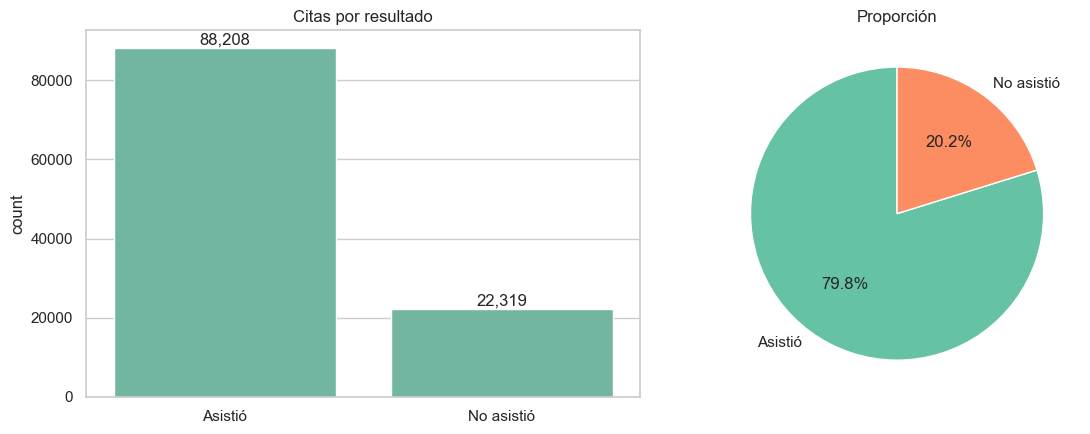

no_show
No     79.81
Yes    20.19
Name: proportion, dtype: float64


In [57]:
conteo = df['no_show'].value_counts()
porcentaje = df['no_show'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x='no_show', ax=ax[0], order=['No', 'Yes'])
ax[0].set_title('Citas por resultado')
ax[0].set_xticklabels(['Asistió', 'No asistió'])
ax[0].set_xlabel('')
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom')

ax[1].pie(conteo[['No', 'Yes']], labels=['Asistió', 'No asistió'], autopct='%1.1f%%',
          startangle=90, colors=sns.color_palette('Set2')[:2])
ax[1].set_title('Proporción')
plt.tight_layout()
plt.show()

print(porcentaje.round(2))

Una de cada cinco citas se pierde (20,2%). Las clases están desbalanceadas, y eso hay que tenerlo en cuenta desde ya: un modelo que diga siempre "asiste" acertaría casi el 80% de las veces sin servir para nada. Por eso más adelante se evalúa con recall, F1 y ROC-AUC y no solo con accuracy.

### 1.9 Tasa de inasistencia por variable

Función auxiliar para calcular y graficar el porcentaje de no-show por categoría.

In [58]:
df['no_show_bin'] = (df['no_show'] == 'Yes').astype(int)  # 1 = no asistió (solo para el EDA)
tasa_global = df['no_show_bin'].mean() * 100

def tasa_no_show(columna, ax=None, titulo=None, orden=None):
    tabla = df.groupby(columna)['no_show_bin'].agg(['mean', 'count'])
    tabla['mean'] *= 100
    if orden is not None:
        tabla = tabla.reindex(orden)
    ax = ax or plt.gca()
    sns.barplot(x=tabla.index.astype(str), y=tabla['mean'], ax=ax, color=sns.color_palette('Set2')[1])
    ax.axhline(tasa_global, ls='--', color='gray', label=f'Promedio ({tasa_global:.1f}%)')
    ax.set_title(titulo or f'% no-show por {columna}')
    ax.set_ylabel('% no asistió')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    return tabla.round(2)

#### Variables demográficas y clínicas

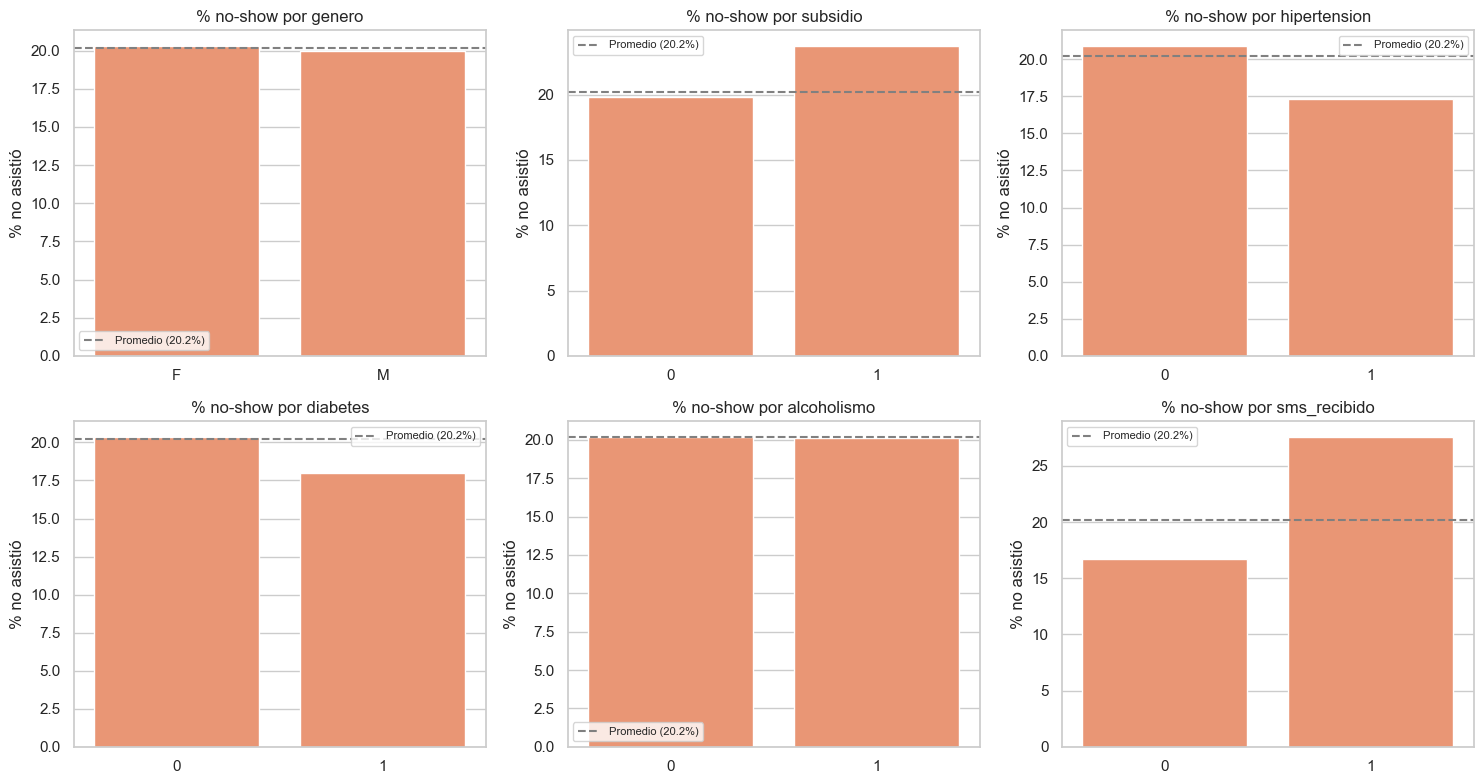

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ['genero', 'subsidio', 'hipertension', 'diabetes', 'alcoholismo', 'sms_recibido']):
    tasa_no_show(col, ax=ax)
plt.tight_layout()
plt.show()

El género y el alcoholismo prácticamente no cambian la tasa. Los pacientes con hipertensión (17,3%) y diabetes (18,0%) faltan menos, posiblemente porque están en controles periódicos. Los beneficiarios del subsidio faltan más (23,7%). El caso del SMS es raro: los que recibieron mensaje faltan más (27,6% contra 16,7%). Eso se revisa más abajo.

#### Edad

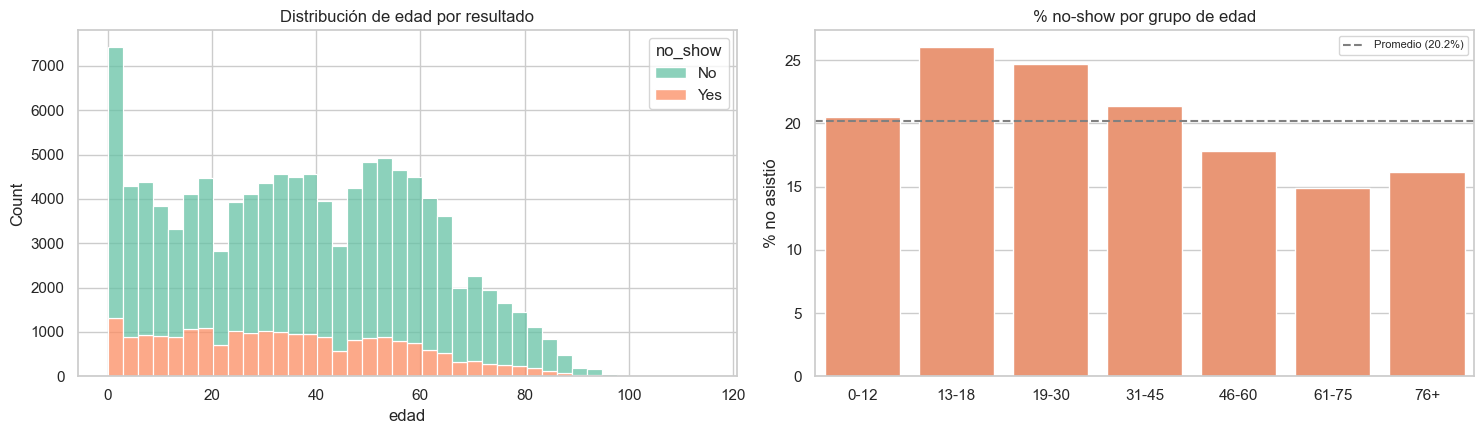

In [60]:
df['grupo_edad'] = pd.cut(df['edad'], bins=[-1, 12, 18, 30, 45, 60, 75, 120],
                          labels=['0-12', '13-18', '19-30', '31-45', '46-60', '61-75', '76+'])

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(data=df[df['edad'] >= 0], x='edad', hue='no_show', bins=40, multiple='stack', ax=ax[0])
ax[0].set_title('Distribución de edad por resultado')
tasa_no_show('grupo_edad', ax=ax[1], titulo='% no-show por grupo de edad')
plt.tight_layout()
plt.show()

Los adolescentes y adultos jóvenes (13 a 30 años) son los que más faltan, alrededor del 25%. A partir de los 45 la tasa baja, y entre 61 y 75 años es la más baja (14,9%).

#### Días de espera

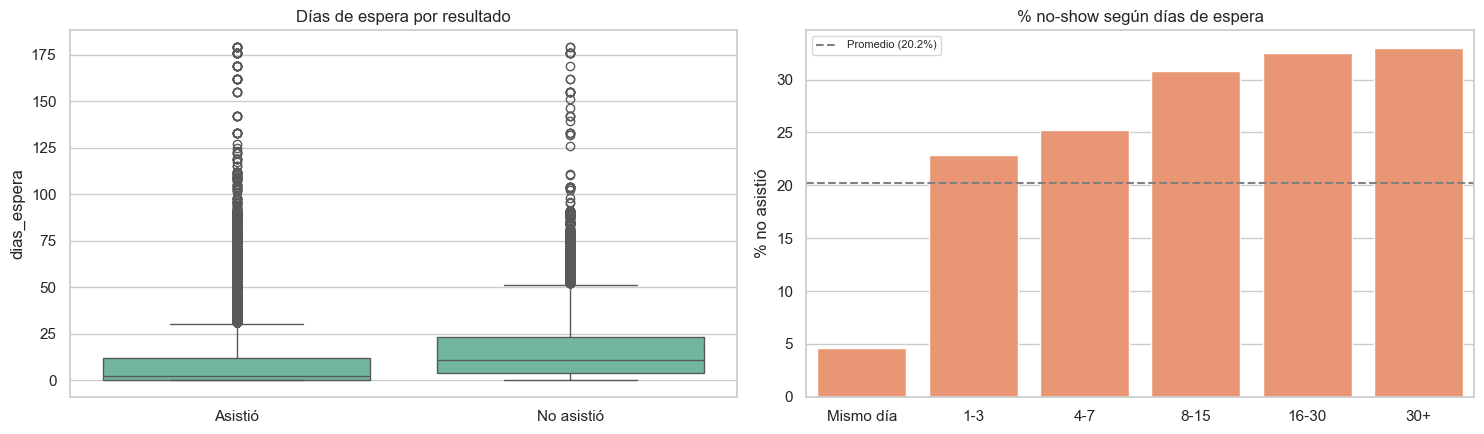

,mean,count
rango_espera,,
Mismo día,4.65,38563
1-3,22.89,14675
4-7,25.20,17510
8-15,30.80,13528
16-30,32.51,15868
30+,33.00,10378


In [61]:
df['rango_espera'] = pd.cut(df['dias_espera'], bins=[-1, 0, 3, 7, 15, 30, 200],
                            labels=['Mismo día', '1-3', '4-7', '8-15', '16-30', '30+'])

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(data=df[df['dias_espera'] >= 0], x='no_show', y='dias_espera', ax=ax[0], order=['No', 'Yes'])
ax[0].set_xticklabels(['Asistió', 'No asistió'])
ax[0].set_title('Días de espera por resultado')
ax[0].set_xlabel('')
tabla_espera = tasa_no_show('rango_espera', ax=ax[1], titulo='% no-show según días de espera')
plt.tight_layout()
plt.show()
tabla_espera

Es la variable con la relación más clara. Cuando la cita es para el mismo día casi nadie falta (4,7%), pero desde el primer día de espera la tasa salta al 23% y sigue subiendo hasta llegar al 33% en citas a más de un mes.

#### Día de la semana

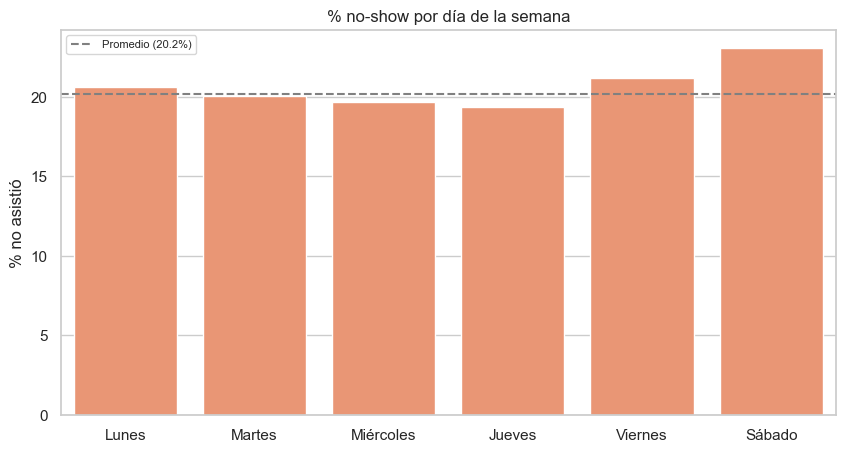

In [62]:
dias_es = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles', 'Thursday': 'Jueves',
           'Friday': 'Viernes', 'Saturday': 'Sábado'}
df['dia_semana'] = df['fecha_cita'].dt.day_name().map(dias_es)

tasa_no_show('dia_semana', titulo='% no-show por día de la semana', orden=list(dias_es.values()))
plt.show()

Las diferencias entre días son pequeñas (entre 19% y 21%). El sábado aparece más alto, pero solo hay 39 citas ese día, así que no es un dato confiable.

#### El caso del SMS

Que el recordatorio aumente la inasistencia no tiene lógica. La explicación está en cómo se envían: en este dataset ninguna cita del mismo día recibió SMS, y casi el 60% de las citas con 3 o más días de espera sí lo recibió. Es decir, el SMS se manda justamente a las citas lejanas, que son las que más se incumplen. Para comprobarlo se compara con y sin SMS dentro de cada rango de espera:

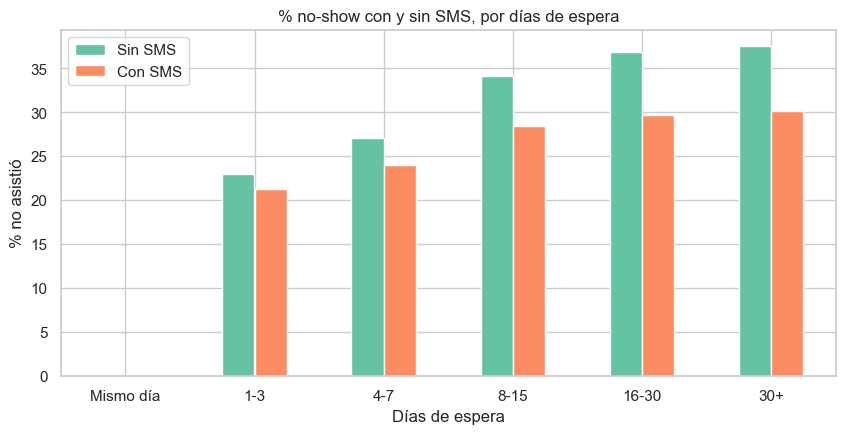

,Sin SMS,Con SMS
rango_espera,,
Mismo día,NaN,NaN
1-3,22.99,21.30
4-7,27.11,23.97
8-15,34.12,28.45
16-30,36.84,29.69
30+,37.53,30.20


In [63]:
tabla_sms = (df[df['dias_espera'] > 0]
             .groupby(['rango_espera', 'sms_recibido'])['no_show_bin'].mean().unstack() * 100)
tabla_sms.columns = ['Sin SMS', 'Con SMS']

tabla_sms.plot(kind='bar', figsize=(10, 4.5), rot=0)
plt.title('% no-show con y sin SMS, por días de espera')
plt.ylabel('% no asistió')
plt.xlabel('Días de espera')
plt.show()
tabla_sms.round(2)

Al comparar citas con la misma espera, el resultado se invierte: con SMS se falta menos en todos los rangos, y la diferencia crece con la espera (en citas de 16 a 30 días baja de 36,8% a 29,7%). El SMS sí funciona; lo que engañaba era la variable de días de espera escondida detrás. Es un buen ejemplo de por qué no se debe sacar conclusiones de una sola variable.

#### Barrios con mayor inasistencia (mínimo 500 citas)

Barrios: 81 en total, 54 con 500 citas o más


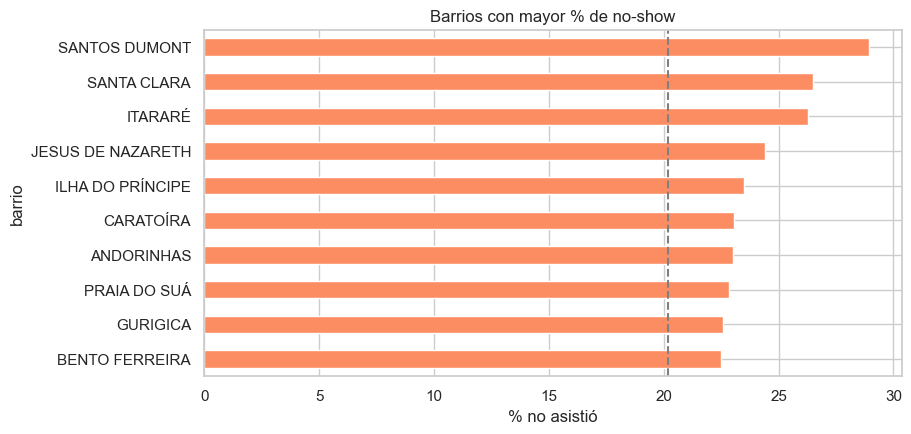

In [64]:
barrios = df.groupby('barrio')['no_show_bin'].agg(['mean', 'count'])
barrios = barrios[barrios['count'] >= 500].sort_values('mean', ascending=False)
barrios['mean'] *= 100

print(f'Barrios: {df["barrio"].nunique()} en total, {len(barrios)} con 500 citas o más')
barrios.head(10).plot(kind='barh', y='mean', legend=False, figsize=(9, 4.5), color=sns.color_palette('Set2')[1])
plt.gca().invert_yaxis()
plt.axvline(tasa_global, ls='--', color='gray')
plt.title('Barrios con mayor % de no-show')
plt.xlabel('% no asistió')
plt.show()

Entre barrios con volumen suficiente la tasa va desde cerca del 16% hasta casi el 29% (Santos Dumont). La ubicación aporta información, pero con 81 categorías hay que codificarla con cuidado.

#### Pacientes con varias citas

In [65]:
citas_por_paciente = df['id_paciente'].value_counts()
print(citas_por_paciente.describe().round(2))
print(f'\nPacientes con más de una cita: {(citas_por_paciente > 1).sum():,} '
      f'({(citas_por_paciente > 1).mean()*100:.1f}%)')

count    62299.00
mean         1.77
std          1.77
min          1.00
25%          1.00
50%          1.00
75%          2.00
max         88.00
Name: count, dtype: float64

Pacientes con más de una cita: 24,379 (39.1%)


El 39% de los pacientes tiene más de una cita en el periodo. Eso permite construir una variable de historial (si el paciente ya ha faltado antes), que se hace en el preprocesamiento.

### 1.10 Correlación

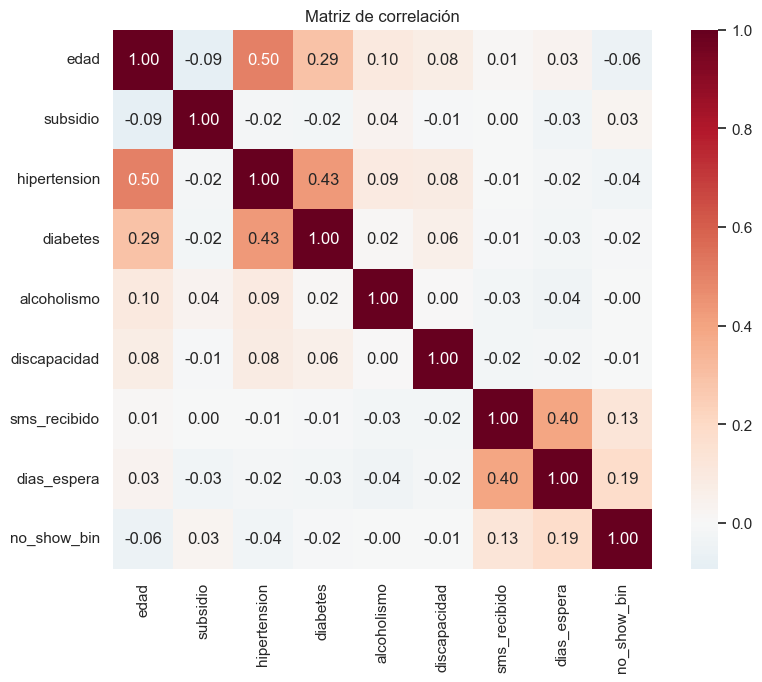

In [66]:
cols_corr = ['edad', 'subsidio', 'hipertension', 'diabetes', 'alcoholismo',
             'discapacidad', 'sms_recibido', 'dias_espera', 'no_show_bin']
plt.figure(figsize=(10, 7))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Matriz de correlación')
plt.show()

### 1.11 Resumen del EDA

- El dataset no tiene nulos ni duplicados. Solo hay 6 registros con errores (edad negativa y fechas incoherentes).
- La inasistencia es del 20,2%, así que las clases están desbalanceadas.
- Los días de espera son el factor más fuerte: las citas del mismo día casi no se pierden.
- Los jóvenes faltan más; los adultos mayores y los pacientes con hipertensión o diabetes faltan menos.
- El SMS parece aumentar la inasistencia, pero al controlar por días de espera se ve que la reduce.
- Las correlaciones lineales con el objetivo son bajas (la más alta es la de días de espera, 0,19). Eso hace pensar que los modelos basados en árboles, que capturan relaciones no lineales, pueden funcionar mejor que uno lineal.

## 2. Preprocesamiento

En esta parte se limpian los errores encontrados, se crean variables nuevas, se dividen los datos y se preparan para los modelos.

Algo importante: todo lo que se calcula a partir de los datos (la codificación de barrios, el escalado) se ajusta únicamente con el conjunto de entrenamiento. Si se usara también el de prueba, el modelo estaría "viendo" información que en la realidad no tendría, y los resultados saldrían inflados (*data leakage*).

### 2.1 Limpieza

In [67]:
df_prep = df.copy()
filas_iniciales = len(df_prep)

df_prep = df_prep[df_prep['edad'] >= 0]          # edad negativa
df_prep = df_prep[df_prep['dias_espera'] >= 0]   # cita antes de su asignación

# discapacidad pasa de nivel 0-4 a sí/no, igual que las demás variables clínicas
df_prep['discapacidad'] = (df_prep['discapacidad'] > 0).astype(int)

print(f'Filas eliminadas: {filas_iniciales - len(df_prep)}')
print(f'Filas finales: {len(df_prep):,}')

Filas eliminadas: 6
Filas finales: 110,521


### 2.2 Variable objetivo

Se deja como 1 = no asistió (la clase que interesa detectar) y 0 = asistió.

In [68]:
df_prep['no_show'] = (df_prep['no_show'] == 'Yes').astype(int)
df_prep['no_show'].value_counts(normalize=True).round(4)

no_show
0    0.7981
1    0.2019
Name: proportion, dtype: float64

### 2.3 Variables nuevas

- `mismo_dia`: 1 si la cita es para el mismo día en que se asignó.
- `dia_semana_cita`: día de la semana de la cita.
- `hora_agendamiento`: hora en que se asignó la cita.
- `num_enfermedades`: suma de hipertensión, diabetes, alcoholismo y discapacidad.
- `citas_previas` y `tasa_no_show_previa`: cuántas citas tuvo antes el paciente y qué proporción de ellas incumplió.

In [69]:
df_prep['mismo_dia'] = (df_prep['dias_espera'] == 0).astype(int)
df_prep['dia_semana_cita'] = df_prep['fecha_cita'].dt.dayofweek  # 0 = lunes
df_prep['hora_agendamiento'] = df_prep['fecha_agendamiento'].dt.hour
df_prep['num_enfermedades'] = df_prep[['hipertension', 'diabetes', 'alcoholismo', 'discapacidad']].sum(axis=1)

#### Historial del paciente

Para cada cita solo se cuentan las citas del mismo paciente con fecha anterior, porque de esas ya se sabe si asistió o no. Si se contaran citas futuras o del mismo día, el modelo usaría información que la IPS no tiene al momento de predecir.

In [70]:
# resumen por paciente y fecha
diario = (df_prep.groupby(['id_paciente', 'fecha_cita'])['no_show']
          .agg(citas_dia='count', no_shows_dia='sum')
          .reset_index()
          .sort_values(['id_paciente', 'fecha_cita']))

# acumulado de los días anteriores (se resta el día actual)
g = diario.groupby('id_paciente')
diario['citas_previas'] = g['citas_dia'].cumsum() - diario['citas_dia']
diario['no_shows_previos'] = g['no_shows_dia'].cumsum() - diario['no_shows_dia']

df_prep = df_prep.merge(diario[['id_paciente', 'fecha_cita', 'citas_previas', 'no_shows_previos']],
                        on=['id_paciente', 'fecha_cita'], how='left')

# tasa histórica; 0 si es la primera cita
df_prep['tasa_no_show_previa'] = np.where(df_prep['citas_previas'] > 0,
                                          df_prep['no_shows_previos'] / df_prep['citas_previas'], 0)

df_prep[['citas_previas', 'no_shows_previos', 'tasa_no_show_previa']].describe().round(3)

,citas_previas,no_shows_previos,tasa_no_show_previa
count,110521.000,110521.000,110521.000
mean,1.176,0.184,0.078
std,3.797,0.612,0.236
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,0.000,0.000,0.000
75%,1.000,0.000,0.000
max,83.000,15.000,1.000


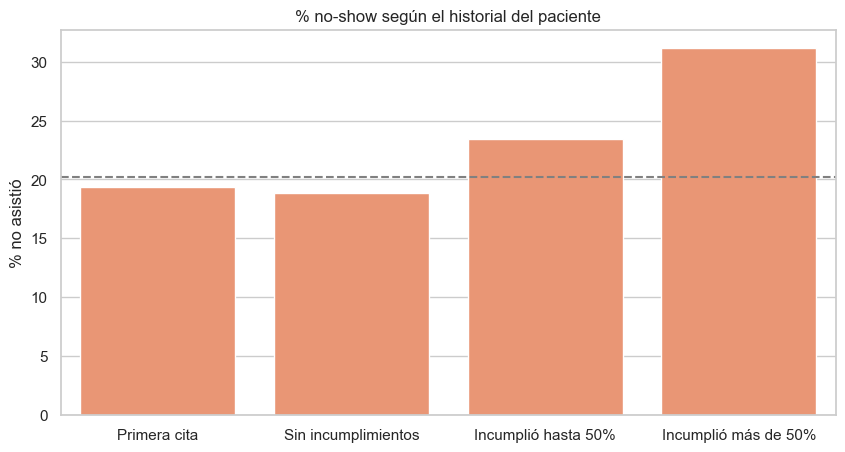

,mean,count
tasa_no_show_previa,,
Primera cita,19.38,66288
Sin incumplimientos,18.85,30119
Incumplió hasta 50%,23.44,7832
Incumplió más de 50%,31.15,6282


In [71]:
# ¿el historial sirve para diferenciar?
hist = pd.cut(df_prep['tasa_no_show_previa'], bins=[-0.01, 0, 0.5, 1],
              labels=['Sin incumplimientos', 'Incumplió hasta 50%', 'Incumplió más de 50%']).astype(str)
hist = hist.where(df_prep['citas_previas'] > 0, 'Primera cita')

orden = ['Primera cita', 'Sin incumplimientos', 'Incumplió hasta 50%', 'Incumplió más de 50%']
tabla_hist = df_prep.groupby(hist)['no_show'].agg(['mean', 'count']).reindex(orden)
tabla_hist['mean'] *= 100

sns.barplot(x=tabla_hist.index, y=tabla_hist['mean'], color=sns.color_palette('Set2')[1])
plt.axhline(df_prep['no_show'].mean() * 100, ls='--', color='gray')
plt.title('% no-show según el historial del paciente')
plt.ylabel('% no asistió')
plt.xlabel('')
plt.show()
tabla_hist.round(2)

Sí sirve: los pacientes que han faltado a más de la mitad de sus citas anteriores tienen una tasa del 31%, contra 19% de los que siempre han asistido.

### 2.4 Selección de variables

Se quitan los identificadores (no tienen patrón, el modelo solo los memorizaría), las fechas originales (ya se sacó de ellas lo útil), las columnas auxiliares del EDA y `no_shows_previos`, que queda repetida con `citas_previas` y `tasa_no_show_previa`.

In [72]:
columnas_eliminar = ['id_paciente', 'id_cita', 'fecha_agendamiento', 'fecha_cita',
                     'grupo_edad', 'rango_espera', 'dia_semana', 'no_show_bin', 'no_shows_previos']
df_modelo = df_prep.drop(columns=[c for c in columnas_eliminar if c in df_prep.columns])

X = df_modelo.drop(columns='no_show')
y = df_modelo['no_show']

print('Variables predictoras:', X.shape[1])
print(list(X.columns))
X.head()

Variables predictoras: 16
['genero', 'edad', 'barrio', 'subsidio', 'hipertension', 'diabetes', 'alcoholismo', 'discapacidad', 'sms_recibido', 'dias_espera', 'mismo_dia', 'dia_semana_cita', 'hora_agendamiento', 'num_enfermedades', 'citas_previas', 'tasa_no_show_previa']


,genero,edad,barrio,subsidio,hipertension,diabetes,alcoholismo,discapacidad,sms_recibido,dias_espera,mismo_dia,dia_semana_cita,hora_agendamiento,num_enfermedades,citas_previas,tasa_no_show_previa
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,1,4,18,1,0,0.0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,1,4,16,0,0,0.0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,1,4,16,0,0,0.0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,1,4,17,0,0,0.0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,1,4,16,2,0,0.0


### 2.5 División entrenamiento / prueba

80% para entrenar y 20% para probar. Con `stratify=y` ambos conjuntos quedan con la misma proporción de no-show, y `random_state=42` permite repetir el resultado.

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Entrenamiento: {X_train.shape[0]:,} filas | no-show: {y_train.mean()*100:.2f}%')
print(f'Prueba:        {X_test.shape[0]:,} filas | no-show: {y_test.mean()*100:.2f}%')

Entrenamiento: 88,416 filas | no-show: 20.19%
Prueba:        22,105 filas | no-show: 20.19%


### 2.6 Codificación de variables categóricas

- `genero` se pasa a 0/1 (F = 1).
- `barrio` tiene 81 categorías. Con one-hot serían 80 columnas casi vacías, así que se usa *target encoding*: cada barrio se reemplaza por su tasa de no-show calculada en entrenamiento. Se aplica un suavizado para que los barrios con pocas citas no queden con tasas extremas.
- `dia_semana_cita` se codifica con one-hot.

In [74]:
for d in (X_train, X_test):
    d['genero'] = (d['genero'] == 'F').astype(int)

# target encoding de barrio, calculado solo con entrenamiento
media_global = y_train.mean()
k = 50  # suavizado: los barrios con pocas citas se acercan a la media general
stats = y_train.groupby(X_train['barrio']).agg(['mean', 'count'])
tasa_barrio = (stats['mean'] * stats['count'] + media_global * k) / (stats['count'] + k)

X_train['barrio_tasa'] = X_train['barrio'].map(tasa_barrio)
X_test['barrio_tasa'] = X_test['barrio'].map(tasa_barrio).fillna(media_global)  # barrio no visto -> media
X_train = X_train.drop(columns='barrio')
X_test = X_test.drop(columns='barrio')

# one-hot del día de la semana
X_train = pd.get_dummies(X_train, columns=['dia_semana_cita'], prefix='dia', drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['dia_semana_cita'], prefix='dia', drop_first=True, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Columnas finales:', X_train.shape[1])
X_train.head()

Columnas finales: 20


,genero,edad,subsidio,hipertension,diabetes,alcoholismo,discapacidad,sms_recibido,dias_espera,mismo_dia,hora_agendamiento,num_enfermedades,citas_previas,tasa_no_show_previa,barrio_tasa,dia_1,dia_2,dia_3,dia_4,dia_5
46756,1,74,0,1,1,0,0,0,35,0,9,2,1,0.0,0.170832,0,0,0,1,0
58858,1,61,0,0,0,0,0,0,1,0,14,0,0,0.0,0.166428,1,0,0,0,0
25707,1,21,0,0,0,0,0,0,14,0,13,0,1,0.0,0.220083,0,0,1,0,0
88574,0,7,0,0,0,0,0,1,20,0,13,0,1,0.0,0.188447,1,0,0,0,0
57364,1,6,0,0,0,0,0,0,36,0,10,0,0,0.0,0.209017,0,0,0,1,0


### 2.7 Escalado

Las variables tienen rangos muy distintos (edad hasta 115, días de espera hasta 179, binarias 0/1). La regresión logística es sensible a eso, así que usa datos escalados. Los modelos de árboles no lo necesitan y trabajan con los datos originales.

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_esc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_esc = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_esc.describe().loc[['mean', 'std']].round(2)

,genero,edad,subsidio,hipertension,diabetes,alcoholismo,discapacidad,sms_recibido,dias_espera,mismo_dia,hora_agendamiento,num_enfermedades,citas_previas,tasa_no_show_previa,barrio_tasa,dia_1,dia_2,dia_3,dia_4,dia_5
mean,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 2.8 Desbalance de clases

Las opciones más comunes son sobremuestrear la clase minoritaria (por ejemplo con SMOTE), submuestrear la mayoritaria o ponderar las clases. Se escoge la ponderación porque no inventa datos ni descarta información: simplemente hace que equivocarse en un no-show le cueste más al modelo. Se aplica con `class_weight='balanced'` en el modelado.

In [76]:
from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
print(f'Peso clase 0 (asistió):    {pesos[0]:.3f}')
print(f'Peso clase 1 (no asistió): {pesos[1]:.3f}')
print(f'Un error en un no-show pesa {pesos[1]/pesos[0]:.1f} veces más que uno en una asistencia.')

Peso clase 0 (asistió):    0.626
Peso clase 1 (no asistió): 2.476
Un error en un no-show pesa 4.0 veces más que uno en una asistencia.


### 2.9 Resumen

- Se eliminaron 6 registros con errores.
- Se agregaron variables nuevas, entre ellas el historial del paciente, calculado solo con citas anteriores.
- División estratificada 80/20; la codificación y el escalado se ajustaron solo con entrenamiento.
- El desbalance se maneja con ponderación de clases.

Conjuntos que quedan: `X_train_esc` y `X_test_esc` para la regresión logística, `X_train` y `X_test` para los modelos de árboles, y `y_train`, `y_test` como objetivo.

## 3. Modelado

Se entrenan tres modelos de tipo diferente:

- **Regresión logística**: modelo lineal, sirve como punto de partida y es fácil de interpretar por sus coeficientes.
- **Random Forest**: muchos árboles entrenados en paralelo con datos distintos (bagging). Capta relaciones no lineales.
- **LightGBM**: árboles entrenados uno tras otro, cada uno corrigiendo los errores del anterior (boosting). Suele ser de los mejores en datos tabulares.

Los tres usan ponderación de clases. Antes se prueba un modelo "tonto" para tener una referencia.

### 3.1 Librerías

In [77]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
import time

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

### 3.2 Modelo de referencia

¿Qué pasa si siempre se predice que el paciente asiste?

In [78]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, pred_dummy):.3f}')
print(f'Recall (no-shows detectados): {recall_score(y_test, pred_dummy):.3f}')

Accuracy: 0.798
Recall (no-shows detectados): 0.000


Casi 80% de accuracy sin detectar un solo no-show. Por eso la métrica principal del proyecto es el **ROC-AUC**, que mide qué tan bien separa el modelo a los que asisten de los que no, sin depender de un umbral. Se acompaña del recall y el F1 de la clase "no asistió".

### 3.3 Regresión logística

In [79]:
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)

inicio = time.time()
cv_lr = cross_validate(modelo_lr, X_train_esc, y_train, cv=cv, scoring=metricas_cv, n_jobs=-1)
modelo_lr.fit(X_train_esc, y_train)
print(f'Tiempo: {time.time() - inicio:.1f} s')

pd.DataFrame(cv_lr).filter(like='test_').mean().round(4)

Tiempo: 3.8 s


test_accuracy     0.5763
test_precision    0.3025
test_recall       0.8416
test_f1           0.4451
test_roc_auc      0.7267
dtype: float64

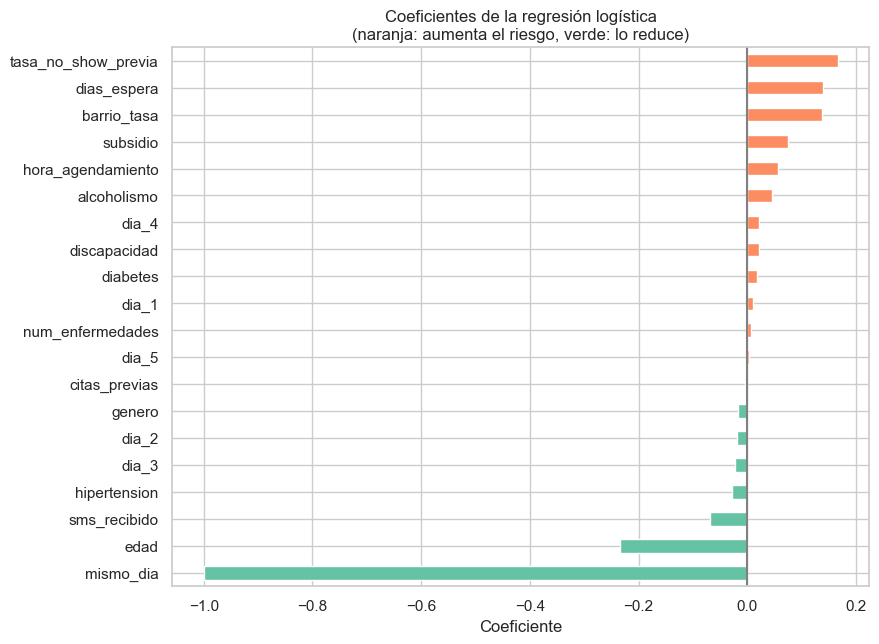

In [80]:
# coeficientes (como las variables están escaladas, se pueden comparar entre sí)
coef = pd.Series(modelo_lr.coef_[0], index=X_train_esc.columns).sort_values()
colores = ['#66c2a5' if c < 0 else '#fc8d62' for c in coef]
coef.plot(kind='barh', color=colores, figsize=(9, 7))
plt.axvline(0, color='gray')
plt.title('Coeficientes de la regresión logística\n(naranja: aumenta el riesgo, verde: lo reduce)')
plt.xlabel('Coeficiente')
plt.show()

### 3.4 Random Forest

Se limita la profundidad y el tamaño mínimo de las hojas para que no se sobreajuste.

In [81]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)

inicio = time.time()
cv_rf = cross_validate(modelo_rf, X_train, y_train, cv=cv, scoring=metricas_cv)
modelo_rf.fit(X_train, y_train)
print(f'Tiempo: {time.time() - inicio:.1f} s')

pd.DataFrame(cv_rf).filter(like='test_').mean().round(4)

Tiempo: 26.1 s


test_accuracy     0.6022
test_precision    0.3142
test_recall       0.8201
test_f1           0.4543
test_roc_auc      0.7446
dtype: float64

### 3.5 LightGBM

Para este modelo se buscan los hiperparámetros con `RandomizedSearchCV`: prueba 20 combinaciones al azar con validación cruzada de 3 pliegues y se queda con la de mejor ROC-AUC. Los parámetros que se ajustan controlan el número de árboles (`n_estimators`), cuánto aprende cada uno (`learning_rate`), su complejidad (`num_leaves`, `max_depth`, `min_child_samples`) y qué porcentaje de filas y columnas ve cada árbol (`subsample`, `colsample_bytree`).

Esta celda puede tardar unos minutos.

In [82]:
param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 6, 10],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}

# n_jobs=1 en el modelo y -1 en la búsqueda, para que cada núcleo pruebe una combinación distinta
base_lgbm = LGBMClassifier(class_weight='balanced', subsample_freq=1, random_state=SEED, verbose=-1, n_jobs=1)

busqueda = RandomizedSearchCV(
    base_lgbm, param_dist, n_iter=20, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1
)

inicio = time.time()
busqueda.fit(X_train, y_train)
print(f'Tiempo: {time.time() - inicio:.1f} s')
print(f'Mejor ROC-AUC (CV): {busqueda.best_score_:.4f}')
print('Mejores hiperparámetros:')
for k, v in busqueda.best_params_.items():
    print(f'  {k}: {v}')

Tiempo: 52.5 s
Mejor ROC-AUC (CV): 0.7472
Mejores hiperparámetros:
  subsample: 0.7
  num_leaves: 63
  n_estimators: 200
  min_child_samples: 50
  max_depth: 10
  learning_rate: 0.03
  colsample_bytree: 1.0


In [83]:
modelo_lgbm = busqueda.best_estimator_
modelo_lgbm.set_params(n_jobs=-1)

cv_lgbm = cross_validate(modelo_lgbm, X_train, y_train, cv=cv, scoring=metricas_cv)
pd.DataFrame(cv_lgbm).filter(like='test_').mean().round(4)

test_accuracy     0.6151
test_precision    0.3194
test_recall       0.8011
test_f1           0.4567
test_roc_auc      0.7471
dtype: float64

### 3.6 Comparación en validación cruzada

Promedio y desviación estándar de los 5 pliegues sobre el conjunto de entrenamiento.

In [84]:
def resumen_cv(resultados, nombre):
    df_r = pd.DataFrame(resultados).filter(like='test_')
    df_r.columns = [c.replace('test_', '') for c in df_r.columns]
    return pd.Series({m: f'{df_r[m].mean():.4f} ± {df_r[m].std():.4f}' for m in df_r.columns}, name=nombre)

tabla_cv = pd.concat([resumen_cv(cv_lr, 'Regresión Logística'),
                      resumen_cv(cv_rf, 'Random Forest'),
                      resumen_cv(cv_lgbm, 'LightGBM')], axis=1).T
tabla_cv

,accuracy,precision,recall,f1,roc_auc
Regresión Logística,0.5763 ± 0.0054,0.3025 ± 0.0031,0.8416 ± 0.0043,0.4451 ± 0.0038,0.7267 ± 0.0037
Random Forest,0.6022 ± 0.0063,0.3142 ± 0.0045,0.8201 ± 0.0102,0.4543 ± 0.0059,0.7446 ± 0.0045
LightGBM,0.6151 ± 0.0068,0.3194 ± 0.0052,0.8011 ± 0.0127,0.4567 ± 0.0068,0.7471 ± 0.0059


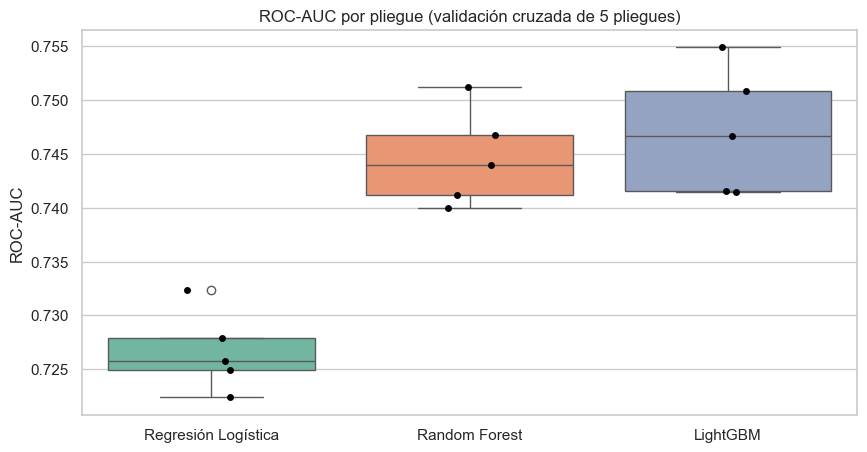

In [85]:
auc_cv = pd.DataFrame({
    'Regresión Logística': cv_lr['test_roc_auc'],
    'Random Forest': cv_rf['test_roc_auc'],
    'LightGBM': cv_lgbm['test_roc_auc'],
})
sns.boxplot(data=auc_cv)
sns.stripplot(data=auc_cv, color='black', size=5)
plt.title('ROC-AUC por pliegue (validación cruzada de 5 pliegues)')
plt.ylabel('ROC-AUC')
plt.show()

Los dos modelos de árboles superan claramente a la regresión logística (ROC-AUC de 0,745 y 0,747 contra 0,727), lo que confirma lo que se veía en el EDA: hay relaciones que no son lineales. Entre Random Forest y LightGBM la diferencia es mínima y sus resultados por pliegue se cruzan, así que en este punto están prácticamente empatados. Los tres son estables, con desviaciones menores a 0,006.

El accuracy de los tres está alrededor del 60%, por debajo del modelo de referencia. Es lo esperado: al ponderar las clases los modelos prefieren marcar de más a un paciente como posible inasistente antes que dejar pasar un no-show, y por eso el recall está por encima del 80%.

### 3.7 Predicciones sobre el conjunto de prueba

Hasta aquí no se ha usado el conjunto de prueba. Se generan las predicciones para evaluarlas en el siguiente módulo.

In [86]:
modelos = {
    'Regresión Logística': (modelo_lr, X_test_esc),
    'Random Forest': (modelo_rf, X_test),
    'LightGBM': (modelo_lgbm, X_test),
}

predicciones = {}
for nombre, (modelo, X_eval) in modelos.items():
    predicciones[nombre] = {
        'proba': modelo.predict_proba(X_eval)[:, 1],  # probabilidad de no asistir
        'pred': modelo.predict(X_eval)                # clase con umbral 0.5
    }
    print(f'{nombre:<20} ROC-AUC prueba: {roc_auc_score(y_test, predicciones[nombre]["proba"]):.4f}')

Regresión Logística  ROC-AUC prueba: 0.7201
Random Forest        ROC-AUC prueba: 0.7372
LightGBM             ROC-AUC prueba: 0.7407


## 4. Evaluación

Se evalúan los tres modelos en el conjunto de prueba (22.105 citas que no se usaron para entrenar) y se escoge el modelo final.

### 4.1 Métricas en prueba

In [87]:
from sklearn.metrics import (precision_score, f1_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve)

filas = []
for nombre, p in predicciones.items():
    filas.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, p['pred']),
        'precision': precision_score(y_test, p['pred']),
        'recall': recall_score(y_test, p['pred']),
        'f1': f1_score(y_test, p['pred']),
        'roc_auc': roc_auc_score(y_test, p['proba']),
        'pr_auc': average_precision_score(y_test, p['proba']),
    })
tabla_test = pd.DataFrame(filas).set_index('modelo').round(4)
tabla_test

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Regresión Logística,0.5738,0.3010,0.8402,0.4432,0.7201,0.3472
Random Forest,0.5951,0.3106,0.8241,0.4511,0.7372,0.3752
LightGBM,0.6072,0.3152,0.8062,0.4532,0.7407,0.3847


`pr_auc` es el área bajo la curva precisión-recall. Es útil cuando la clase de interés es minoritaria: un modelo al azar sacaría alrededor de 0,20 (la proporción de no-shows).

Los resultados en prueba son muy parecidos a los de validación cruzada, lo que indica que los modelos generalizan bien a datos nuevos. LightGBM queda primero en ROC-AUC (0,741), PR-AUC (0,385), F1 y precisión. Random Forest queda muy cerca y la regresión logística un poco más atrás. Los tres casi duplican el PR-AUC que se obtendría al azar.

### 4.2 Matrices de confusión (umbral 0,5)

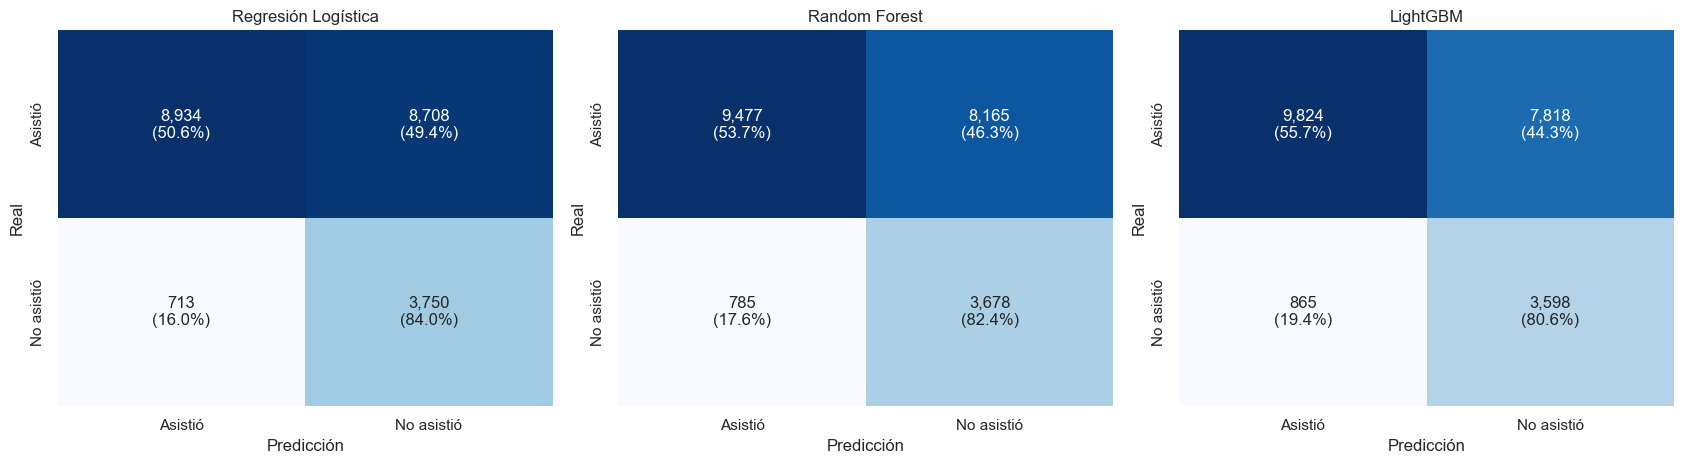

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
etiquetas = ['Asistió', 'No asistió']

for ax, (nombre, p) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, p['pred'])
    pct = cm / cm.sum(axis=1, keepdims=True) * 100
    texto = np.array([[f'{cm[i, j]:,}\n({pct[i, j]:.1f}%)' for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=texto, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=etiquetas, yticklabels=etiquetas)
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

Las tres matrices se parecen: los modelos detectan entre el 81% y el 84% de los no-shows, a cambio de marcar como riesgosas a cerca de la mitad de las citas que sí se cumplieron. La diferencia está en esos falsos positivos: LightGBM marca 7.817 citas que sí se cumplieron, unas 570 menos que Random Forest y unas 900 menos que la regresión logística, a cambio de dejar pasar algunos no-shows más. Para la IPS cada falso positivo es una llamada de recordatorio que no hacía falta, que es un costo bajo comparado con perder la cita.

### 4.3 Curvas ROC

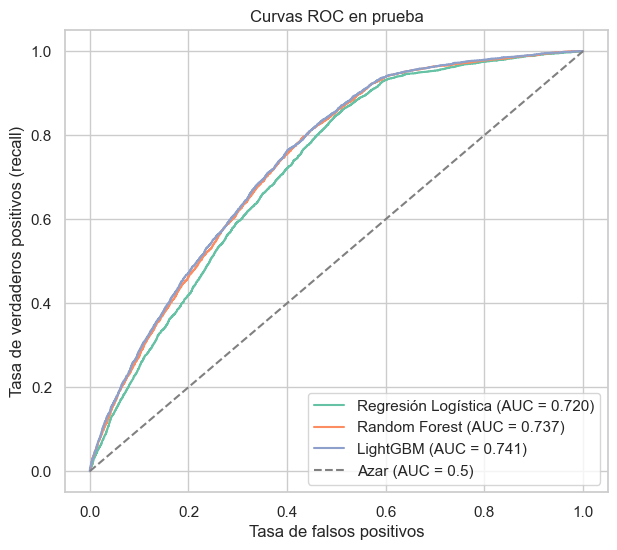

In [89]:
plt.figure(figsize=(7, 6))
for nombre, p in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, p['proba'])
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc_score(y_test, p["proba"]):.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Curvas ROC en prueba')
plt.legend()
plt.show()

### 4.4 Curvas precisión-recall

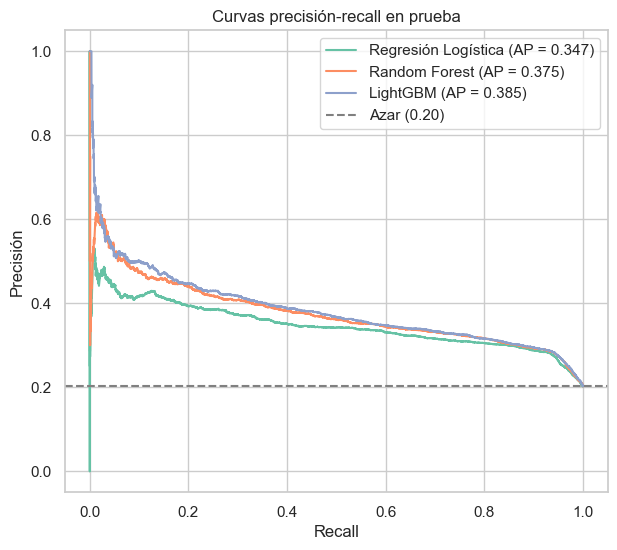

In [90]:
plt.figure(figsize=(7, 6))
for nombre, p in predicciones.items():
    prec, rec, _ = precision_recall_curve(y_test, p['proba'])
    plt.plot(rec, prec, label=f'{nombre} (AP = {average_precision_score(y_test, p["proba"]):.3f})')
plt.axhline(y_test.mean(), ls='--', color='gray', label=f'Azar ({y_test.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curvas precisión-recall en prueba')
plt.legend()
plt.show()

Las curvas ROC de Random Forest y LightGBM casi se superponen y están siempre por encima de la regresión logística. En la curva precisión-recall se ve lo mismo, con LightGBM ligeramente arriba en casi todo el recorrido.

### 4.5 Sobreajuste

Se compara el ROC-AUC en entrenamiento con el de prueba. Si la diferencia es grande, el modelo memorizó en lugar de aprender.

In [91]:
sobreajuste = pd.DataFrame({
    'AUC entrenamiento': [roc_auc_score(y_train, modelo_lr.predict_proba(X_train_esc)[:, 1]),
                          roc_auc_score(y_train, modelo_rf.predict_proba(X_train)[:, 1]),
                          roc_auc_score(y_train, modelo_lgbm.predict_proba(X_train)[:, 1])],
    'AUC prueba': tabla_test['roc_auc'].values
}, index=tabla_test.index)
sobreajuste['diferencia'] = sobreajuste['AUC entrenamiento'] - sobreajuste['AUC prueba']
sobreajuste.round(4)

,AUC entrenamiento,AUC prueba,diferencia
modelo,,,
Regresión Logística,0.7273,0.7201,0.0072
Random Forest,0.7856,0.7372,0.0484
LightGBM,0.7847,0.7407,0.0440


La regresión logística prácticamente no se sobreajusta, pero tampoco aprende tanto. Los modelos de árboles tienen una diferencia de unos 0,045 puntos entre entrenamiento y prueba. Es un sobreajuste moderado y aceptable: el rendimiento en prueba sigue siendo el mejor, y es consistente con la validación cruzada.

### 4.6 Probabilidades predichas contra el valor real

Se compara la probabilidad que asigna el LightGBM con lo que realmente pasó. Si el modelo funciona, los que no asistieron deberían concentrarse en probabilidades altas.

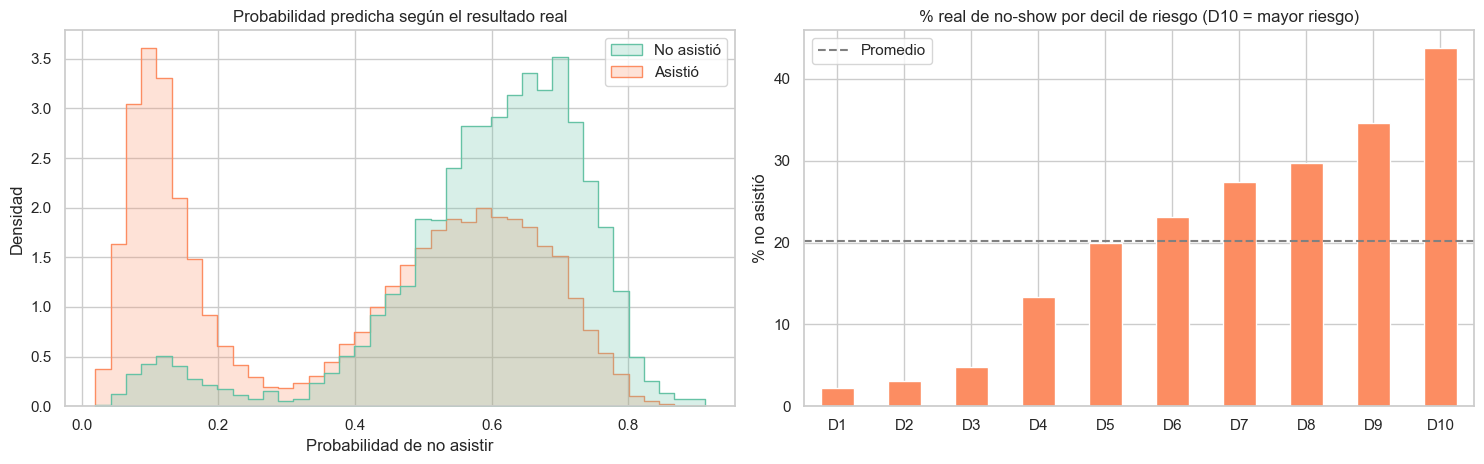

D1      2.2
D2      3.0
D3      4.7
D4     13.3
D5     19.9
D6     23.1
D7     27.4
D8     29.8
D9     34.7
D10    43.7
dtype: float64

In [92]:
proba_lgbm = predicciones['LightGBM']['proba']

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
sns.histplot(x=proba_lgbm, hue=y_test.map({0: 'Asistió', 1: 'No asistió'}).values,
             bins=40, stat='density', common_norm=False, element='step', ax=ax[0])
ax[0].set_title('Probabilidad predicha según el resultado real')
ax[0].set_xlabel('Probabilidad de no asistir')
ax[0].set_ylabel('Densidad')

# por deciles de riesgo: tasa real de no-show en cada grupo
deciles = pd.qcut(proba_lgbm, 10, labels=[f'D{i}' for i in range(1, 11)])
tasa_decil = pd.Series(y_test.values).groupby(deciles).mean() * 100
tasa_decil.plot(kind='bar', ax=ax[1], color=sns.color_palette('Set2')[1], rot=0)
ax[1].axhline(y_test.mean() * 100, ls='--', color='gray', label='Promedio')
ax[1].set_title('% real de no-show por decil de riesgo (D10 = mayor riesgo)')
ax[1].set_ylabel('% no asistió')
ax[1].set_xlabel('')
ax[1].legend()
plt.tight_layout()
plt.show()
tasa_decil.round(1)

En el histograma, las citas que se perdieron se concentran en probabilidades altas y las que se cumplieron en probabilidades bajas, aunque hay bastante superposición, lo normal en un problema de comportamiento humano. El pico de la izquierda, cerca de 0,1, corresponde casi todo a citas del mismo día, que el modelo reconoce como de muy bajo riesgo. La gráfica de deciles muestra mejor lo que hace el modelo: en el 10% de citas con menor riesgo solo falta el 2,2% de los pacientes, mientras que en el 10% de mayor riesgo falta el 43,7%, más del doble del promedio. El riesgo real sube de forma ordenada decil a decil, o sea que la probabilidad que da el modelo sí sirve para ordenar a los pacientes.

### 4.7 Importancia de variables

Se usan dos medidas. La importancia propia del LightGBM (cuánto mejora el modelo cada vez que usa la variable) y la importancia por permutación, que mide cuánto cae el ROC-AUC en prueba si se desordena esa variable. La segunda es más confiable porque se calcula con datos que el modelo no vio.

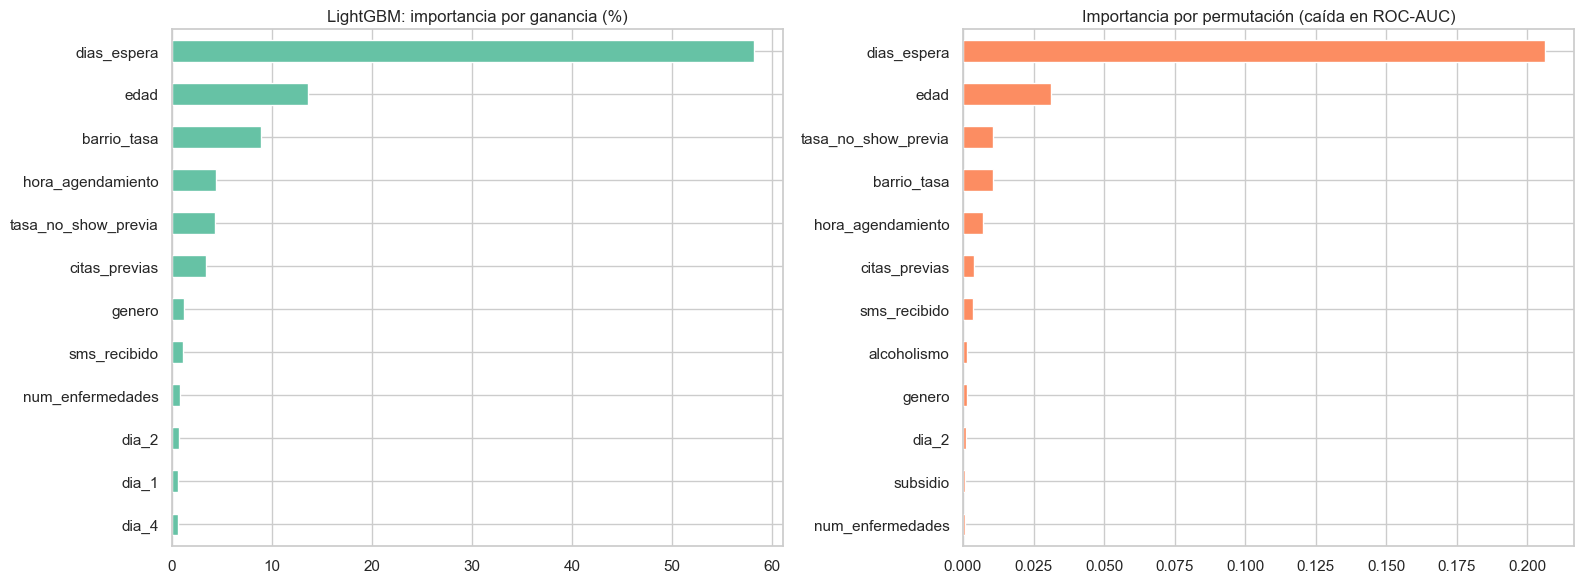

,ganancia_%,permutacion
dias_espera,58.1536,0.2062
edad,13.5867,0.0313
tasa_no_show_previa,4.3319,0.0107
barrio_tasa,8.9367,0.0106
hora_agendamiento,4.3745,0.0070
citas_previas,3.4128,0.0040
sms_recibido,1.0957,0.0036
alcoholismo,0.4049,0.0014
genero,1.2273,0.0013
dia_2,0.7145,0.0011


In [93]:
from sklearn.inspection import permutation_importance

imp_gain = pd.Series(modelo_lgbm.booster_.feature_importance(importance_type='gain'),
                     index=X_train.columns)
imp_gain = imp_gain / imp_gain.sum() * 100

perm = permutation_importance(modelo_lgbm, X_test, y_test, scoring='roc_auc',
                              n_repeats=5, random_state=SEED, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=X_test.columns)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
imp_gain.sort_values().tail(12).plot(kind='barh', ax=ax[0], color=sns.color_palette('Set2')[0])
ax[0].set_title('LightGBM: importancia por ganancia (%)')
imp_perm.sort_values().tail(12).plot(kind='barh', ax=ax[1], color=sns.color_palette('Set2')[1])
ax[1].set_title('Importancia por permutación (caída en ROC-AUC)')
plt.tight_layout()
plt.show()

pd.DataFrame({'ganancia_%': imp_gain, 'permutacion': imp_perm}).sort_values('permutacion', ascending=False).round(4).head(10)

Las dos medidas coinciden en lo principal. Los días de espera son, por mucho, la variable más importante: si se desordenan, el ROC-AUC cae unos 0,21 puntos, y el modelo quedaría casi al nivel del azar. Después vienen la edad, el historial de inasistencia del paciente, el barrio y la hora en que se asignó la cita. Las variables clínicas aportan muy poco. El SMS también pesa poco, y tiene sentido: como se vio en el EDA, se envía según los días de espera, así que buena parte de su información ya está en esa variable.

### 4.8 Ajuste del umbral

Por defecto el modelo marca como no-show a todo paciente con probabilidad mayor a 0,5. Ese valor no es obligatorio; se puede mover según lo que necesite la IPS. Un umbral más bajo detecta más no-shows pero genera más llamadas innecesarias, y uno más alto hace lo contrario.

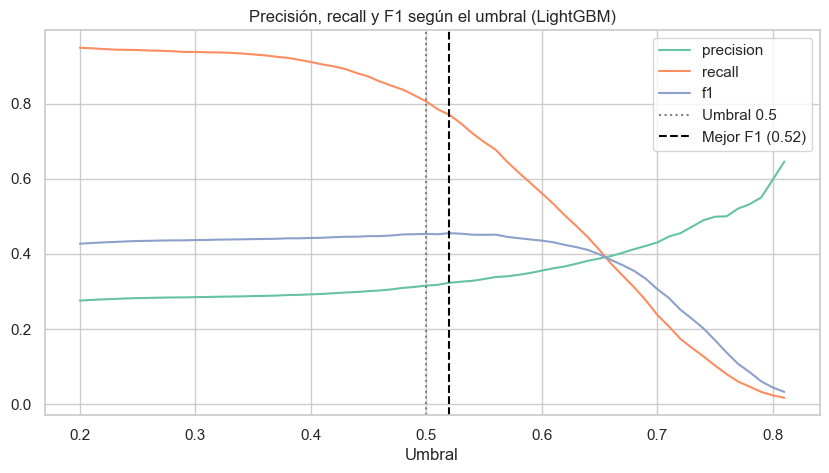

,umbral,precision,recall,f1,pct_marcados
20,0.40,0.292,0.911,0.442,63.008
30,0.50,0.315,0.806,0.453,51.644
32,0.52,0.323,0.771,0.455,48.184
40,0.60,0.355,0.562,0.435,31.916
50,0.70,0.430,0.237,0.306,11.133


In [94]:
umbrales = np.arange(0.20, 0.81, 0.01)
curva = pd.DataFrame({
    'umbral': umbrales,
    'precision': [precision_score(y_test, proba_lgbm >= u, zero_division=0) for u in umbrales],
    'recall': [recall_score(y_test, proba_lgbm >= u) for u in umbrales],
    'f1': [f1_score(y_test, proba_lgbm >= u) for u in umbrales],
    'pct_marcados': [(proba_lgbm >= u).mean() * 100 for u in umbrales],
})

mejor = curva.loc[curva['f1'].idxmax()]
umbral_optimo = round(mejor['umbral'], 2)

plt.figure(figsize=(10, 5))
for m in ['precision', 'recall', 'f1']:
    plt.plot(curva['umbral'], curva[m], label=m)
plt.axvline(0.5, ls=':', color='gray', label='Umbral 0.5')
plt.axvline(umbral_optimo, ls='--', color='black', label=f'Mejor F1 ({umbral_optimo})')
plt.xlabel('Umbral')
plt.title('Precisión, recall y F1 según el umbral (LightGBM)')
plt.legend()
plt.show()

curva[curva['umbral'].round(2).isin([0.4, 0.5, umbral_optimo, 0.6, 0.7])].round(3)

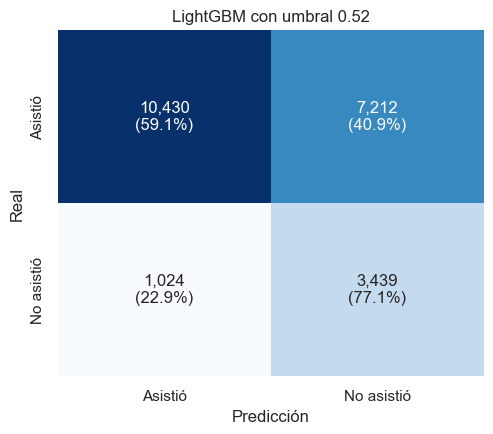

Accuracy:  0.627
Precisión: 0.323
Recall:    0.771
F1:        0.455


In [95]:
pred_opt = (proba_lgbm >= umbral_optimo).astype(int)
cm = confusion_matrix(y_test, pred_opt)
pct = cm / cm.sum(axis=1, keepdims=True) * 100
texto = np.array([[f'{cm[i, j]:,}\n({pct[i, j]:.1f}%)' for j in range(2)] for i in range(2)])

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=texto, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Asistió', 'No asistió'], yticklabels=['Asistió', 'No asistió'])
plt.title(f'LightGBM con umbral {umbral_optimo}')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print(f'Accuracy:  {accuracy_score(y_test, pred_opt):.3f}')
print(f'Precisión: {precision_score(y_test, pred_opt):.3f}')
print(f'Recall:    {recall_score(y_test, pred_opt):.3f}')
print(f'F1:        {f1_score(y_test, pred_opt):.3f}')

El umbral con mejor F1 es 0,52, prácticamente el mismo 0,5 por defecto, y la curva de F1 es bastante plana entre 0,4 y 0,6. Eso quiere decir que el F1 no es el mejor criterio para escoger el umbral en este caso. La decisión depende más de cuántos pacientes puede contactar la IPS: con 0,4 se detecta el 91% de los no-shows pero hay que contactar al 63% de las citas, y con 0,6 se contacta al 32% y se detecta el 56%. Eso se analiza en el siguiente punto.

### 4.9 Uso práctico: ¿a quién llamar?

En la práctica una IPS no tiene personal para llamar a todos los pacientes, así que la pregunta útil es: si solo se puede contactar a cierto porcentaje de las citas, ¿qué porcentaje de los no-shows se alcanza a cubrir? Se ordenan las citas de mayor a menor riesgo y se compara con escoger al azar.

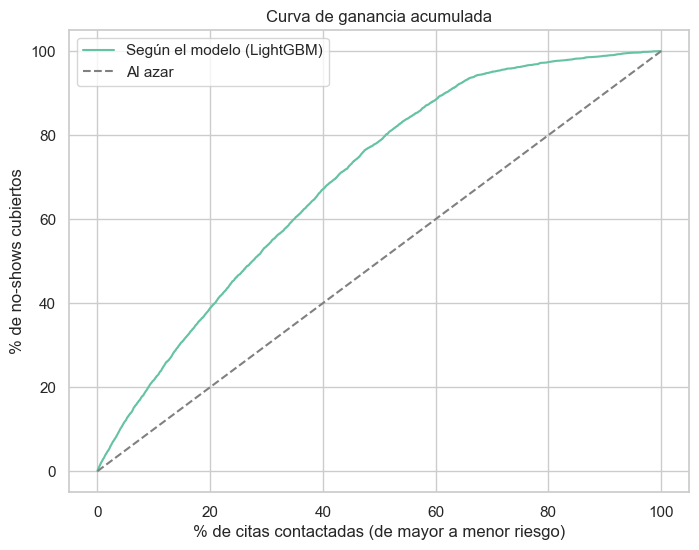

,% citas contactadas,% no-shows cubiertos,veces mejor que al azar
0,10,21.6,2.2
1,20,38.8,1.9
2,30,53.6,1.8
3,40,67.2,1.7
4,50,78.6,1.6


In [96]:
orden = np.argsort(-proba_lgbm)
y_ordenado = y_test.values[orden]
capturados = np.cumsum(y_ordenado) / y_ordenado.sum() * 100
pct_contactado = np.arange(1, len(y_ordenado) + 1) / len(y_ordenado) * 100

plt.figure(figsize=(8, 6))
plt.plot(pct_contactado, capturados, label='Según el modelo (LightGBM)')
plt.plot([0, 100], [0, 100], '--', color='gray', label='Al azar')
plt.xlabel('% de citas contactadas (de mayor a menor riesgo)')
plt.ylabel('% de no-shows cubiertos')
plt.title('Curva de ganancia acumulada')
plt.legend()
plt.show()

ganancia = pd.DataFrame({'% citas contactadas': [10, 20, 30, 40, 50]})
ganancia['% no-shows cubiertos'] = [capturados[int(len(capturados) * p / 100) - 1] for p in ganancia['% citas contactadas']]
ganancia['veces mejor que al azar'] = ganancia['% no-shows cubiertos'] / ganancia['% citas contactadas']
ganancia.round(1)

Si la IPS solo puede llamar al 20% de las citas, escogiéndolas con el modelo cubre el 38,8% de los no-shows, casi el doble que escogiéndolas al azar. Con el 30% cubre más de la mitad (53,6%). Esta es la forma más práctica de usar el modelo: no hace falta escoger un umbral fijo, basta con ordenar la agenda del día siguiente por riesgo y llamar hasta donde alcance el personal.

### 4.10 Modelo seleccionado

Los resultados en prueba son muy parecidos a los de validación cruzada, lo que indica que los modelos generalizan bien a datos nuevos. LightGBM queda primero en ROC-AUC (0,741), PR-AUC (0,385), F1 y precisión. Random Forest queda muy cerca y la regresión logística un poco más atrás. Los tres casi duplican el PR-AUC que se obtendría al azar.0

## 5. Conclusiones

### Sobre el problema

El objetivo era estimar, con la información disponible al momento de asignar la cita, qué tan probable es que un paciente no asista. El modelo final (LightGBM) logra un ROC-AUC de 0,741 en datos que no vio durante el entrenamiento. No predice con certeza quién va a faltar, pero sí ordena a los pacientes por riesgo con mucha más precisión que el azar: en el 10% de citas que el modelo considera más riesgosas falta el 43,7% de los pacientes, y en el 10% menos riesgoso solo el 2,2%.

### Qué explica la inasistencia

- **Los días de espera son el factor principal.** Las citas del mismo día casi no se pierden (4,7%), y en las que se asignan con más de un mes de anticipación falta uno de cada tres pacientes. Es la variable más importante en todos los modelos.
- **La edad influye.** Los pacientes entre 13 y 30 años son los que más faltan; los adultos mayores, los que menos.
- **El historial cuenta.** Un paciente que ya ha faltado a más de la mitad de sus citas anteriores tiene una tasa de inasistencia del 31%, contra 19% de quien siempre ha asistido.
- **El SMS sí ayuda.** A primera vista parecía aumentar la inasistencia, pero al comparar citas con la misma espera se ve que la reduce en todos los rangos. Fue un caso claro de una variable escondida (los días de espera) que distorsionaba la relación.
- **Las condiciones clínicas pesan poco.** Los pacientes con hipertensión o diabetes faltan algo menos, pero para el modelo estas variables casi no aportan.

### Sobre los modelos

| Modelo | ROC-AUC (CV) | ROC-AUC (prueba) | F1 (prueba) |
|---|---|---|---|
| Regresión logística | 0,727 | 0,720 | 0,443 |
| Random Forest | 0,745 | 0,737 | 0,449 |
| LightGBM | 0,747 | 0,741 | 0,453 |

Los modelos de árboles superaron a la regresión logística, lo que confirma que las relaciones entre las variables y la inasistencia no son lineales. LightGBM se escogió porque tuvo el mejor resultado en todas las métricas principales, genera menos llamadas innecesarias que los otros dos con un recall similar, y es estable y rápido de entrenar. Su ventaja sobre Random Forest es pequeña.

También quedó claro por qué el accuracy no sirve en este problema: un modelo que siempre dice "asiste" llega casi al 80% sin detectar un solo no-show.

### Limitaciones

- Los datos son de Brasil y de 2016, de un periodo de apenas seis semanas de citas. El comportamiento de los pacientes en Colombia, o en otra época, puede ser diferente, así que el modelo no se puede usar tal cual en otra institución sin reentrenarlo con sus propios datos.
- Faltan variables que probablemente explican mucho de la inasistencia: especialidad, tipo de cita (primera vez o control), distancia al centro de salud, aseguradora o régimen, clima, etc.
- El historial del paciente solo cubre el periodo del dataset; con más tiempo de datos esta variable sería más útil.
- Un ROC-AUC de 0,74 es bueno para un problema de comportamiento humano, pero el modelo se equivoca seguido en casos individuales. Debe usarse para priorizar, no para tomar decisiones sobre un paciente en particular (por ejemplo, negarle una cita).

### Recomendaciones para una IPS

1. **Usar el modelo para priorizar recordatorios.** Cada día se ordena la agenda del día siguiente por riesgo y se llama primero a los de mayor riesgo, hasta donde alcance el personal. Llamando al 20% de las citas se cubre casi el 40% de las inasistencias.
2. **Reducir los tiempos de espera cuando sea posible**, por ejemplo reservando cupos de asignación cercana, ya que es el factor que más pesa.
3. **Mantener y ampliar los recordatorios por SMS**, que según los datos sí reducen la inasistencia.
4. **Considerar la sobreasignación controlada** en las franjas donde el modelo prevé más inasistencias, para no perder capacidad.

### Trabajo futuro: aplicación en la IPS donde trabajo

El siguiente paso es llevar este enfoque a la IPS donde trabajo, con datos reales de consulta externa. Antes de usar cualquier dato de pacientes habría que tener la autorización de la institución y cumplir con la Ley 1581 de 2012 de protección de datos personales, trabajando con información anonimizada. El plan sería:

1. Extraer el histórico de citas del sistema de la IPS y anonimizarlo.
2. Agregar variables propias del contexto colombiano: EPS, régimen (subsidiado o contributivo), especialidad, tipo de cita, zona de residencia (urbana o rural) y días de espera.
3. Repetir el flujo de este proyecto (exploración, preprocesamiento, modelado y evaluación) y reentrenar el modelo con esos datos.
4. Medir el impacto con una prueba piloto: comparar la inasistencia de un periodo con llamadas priorizadas por el modelo contra uno sin el modelo.
5. Si funciona, integrarlo en una herramienta sencilla que genere cada día la lista de pacientes a llamar, y reentrenarlo periódicamente.